# Bayesian Logistic Regression with M-SVGD-EM



In [ ]:
#!pip install numpy scipy matplotlib seaborn tensorflow-probability optax pandas scikit-learn wget

In [ ]:
#!pip install -e "C:/path/to/CoinEM-main(replace with the path to the CoinEM-main folder)"

In [1]:
import os
import time
from dataclasses import dataclass
import numpy as np
from scipy import stats  # stats to generate KDEs
import jax.numpy as jnp
import jax.random as jr
from jax import vmap
import matplotlib.pyplot as plt
import seaborn as sns  # for heatmap
from matplotlib.colors import LinearSegmentedColormap

# TensorFlow Probability
import tensorflow_probability.substrates.jax as tfp
import tensorflow_probability.substrates.jax.distributions as tfd

# CoinEM 
from jaxtyping import Array, Float, PyTree
from coinem.model import AbstractModel
from coinem.dataset import Dataset
from coinem.zoo import coin_svgd, pgd, soul, adam_svgd, m_svgd_em,mpgd

# Optimizers
import optax as ox

In [2]:
# save_dir = "figures_MedianRBF"
# os.makedirs(save_dir, exist_ok=True)
save_dir = "figures_final"
os.makedirs(save_dir, exist_ok=True)

## Model

We employ standard Bayesian logistic regression with Gaussian priors. That is, we assume that the datapoints’ labels are conditionally independent given the features $f$ and regression weights $x \in \mathbb{R}^{Dy:=9}$, each label with Bernoulli law and mean $s(f^T x)$, where $s(z) := e^z/(1 + e^z)$ denotes the standard logistic function; and we assign the prior $\mathcal{N}(x; \theta I_{D_y}, 5I_{D_y})$ to the weights $x$, where $\theta$ denotes the (scalar) parameter to be estimated. The model’s density is given by:

$$ p_\theta(x, y) = \mathcal{N}(x; \theta I_{D_y}, 5I_{D_y}) \prod_{f, l} s(f^{T} x)^{l} \left[ 1 - s(f^{T} x) \right]^{1-l}$$

### Model in code:
To create our model we just inherit from the provided `AbstractModel`.

In [3]:
from jaxtyping import Array, Float, PyTree
import tensorflow_probability.substrates.jax.bijectors as tfb
#We employ standard Bayesian logistic regression with Gaussian priors. 
# That is, we assume that the datapoints’ labels are conditionally independent given the features $f$ and regression weights $x \in \mathbb{R}^{Dy:=9}$, each label with Bernoulli law and mean $s(f^T x)$,
# where $s(z) := e^z/(1 + e^z)$ denotes the standard logistic function; and we assign the prior $\mathcal{N}(x; \theta I_{D_y}, 5I_{D_y})$ to the weights $x$, where $\theta$ denotes the (scalar) parameter to be estimated. 
#The model’s density is given by:
@dataclass
class LogisticRegression(AbstractModel):
    """Base class for p(θ, x)."""
    
    def log_prob(self, latent: Float[Array, "D 1"], theta: Float[Array, "Q"], data: Dataset) -> Float[Array, ""]:
        """Compute gradient of the objective function at x.

        Args:
            latent (Float[Array, "D"]): Input weights of shape (D,).
            theta (Float[Array, "Q"]): Parameters of shape (Q,).

        Returns:            Float[Array, ""]: log-probability of the data.
        """

        # Compute linear predictor.
        z = jnp.matmul(data.X, latent)

        # likelihood
        log_lik = tfd.Bernoulli(logits=z).log_prob(data.y.squeeze()).sum()

        # Prior
        log_prior = tfd.Normal(loc=theta, scale=5.0).log_prob(latent).sum().squeeze()

        # Compute log-probability.
        return log_lik + log_prior
    
    def optimal_theta(self, latent_particles: PyTree[Float[Array, "N D *"]]) -> PyTree[Float[Array, "Q *"]]:
        return latent_particles.mean().reshape(-1)

### Dataset:

We use the Wisconsin Breast Cancer dataset Y (Wolberg and Mangasarian, 1990), created by Dr. William H. Wolberg at the University of Wisconsin Hospitals, and freely available at
https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(original).
It contains 683 datapoints5 each with nine features f ∈ R9 extracted from a digitized image of a fine needle aspirate of a breast mass and an accompanying label l indicating whether the mass is benign (l = 0) or malign (l = 1). We normalize the features so that each has mean zero and unit standard deviation across the dataset. We split the dataset into 80/20 training and testing sets, Ytrain and Ytest.

In [6]:
# OS and wget to load dataset.
import os
import wget
import numpy as np

# Fetch dataset from repository:
wget.download('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data')

# Load dataset:
dataset = np.loadtxt('breast-cancer-wisconsin.data', dtype=str, delimiter=',')

# Delete local copy of dataset to avoid duplicates with multiple notebook runs:
os.remove('breast-cancer-wisconsin.data')

# Remove datapoints with missing attributes and change dtype to float:
dataset = dataset[~(dataset == '?').any(axis=1), :].astype(float)

# Extract features and labels, and normalize features:
features = np.array(dataset[:, 1:10] - dataset[:, 1:10].mean(0))
features = features/features.std(0)
labels = np.array([(dataset[:, 10]-2)/2]).transpose()

# Split data into 80/20 training and testing sets:
from sklearn.model_selection import train_test_split
ftrain, ftest, ltrain, ltest = train_test_split(features, labels, test_size=0.2, 
                                                random_state=45)

### Unit tests:
We test the score of the latent function and average log-probability of the model.

In [7]:
model = LogisticRegression()
data = Dataset(ftrain, ltrain)

# Unit tests:
N = 10  # Number of particles.
D = 9  # Dimension of latent space.

theta = jnp.array([0.0]) # Parameters of the model.
latent_particles = jnp.zeros((N, D)) # Latent particles.

f = ftrain # Features
y = ltrain # Labels

s = 1.0/(1.0+jnp.exp(-jnp.matmul(f, latent_particles.T)))
score_latent_particles = (jnp.matmul((y-s).T, f).T - (latent_particles.T)/5).T
average_score_theta = jnp.array([[2 * (latent_particles.T).sum(0).mean()/5]])

assert jnp.allclose(model.score_latent_particles(latent_particles, theta, data), score_latent_particles) # Gradient of log p(y|x) wrt latent particles
assert jnp.allclose(model.average_score_theta(latent_particles, theta, data), average_score_theta) # Average gradient of log p(y|x) wrt theta

In [8]:
colors = {
    'pgd': '#9932CC',      #Purple
    'mpgd': '#4169E1',     #Blue purple
    'soul': '#0000CD',     #Dark blue
    'svgd': '#8B0000',     #Dark red
    'acc03': '#FF3333',    #Lighter red
    'acc05': '#FF8C00',    #Orange
    'acc09': '#228B22'     #Green
}


In [8]:
start=time.time()

# Experiment 1 (Theta estimate example - Kuntz et al.) Changed for M-SVGD-EM

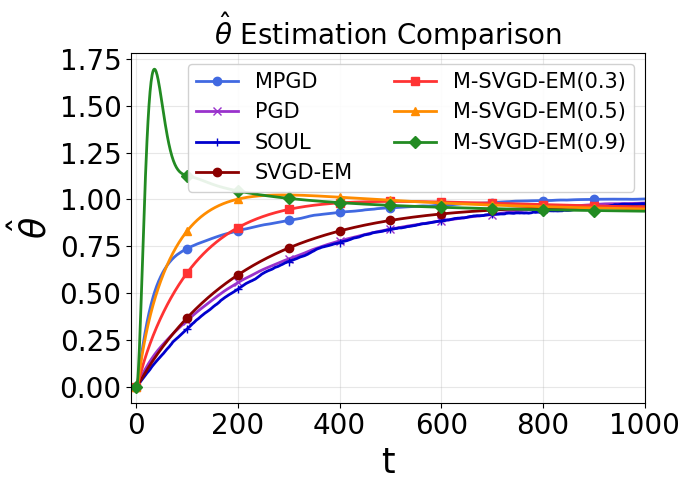

In [9]:
from coinem.zoo import coin_svgd, pgd, soul, adam_svgd,m_svgd_em,mpgd
from coinem.marginal_zoo import marginal_coin_svgd
import optax as ox
import jax.random as jr
import matplotlib.pyplot as plt
import os
key = jr.PRNGKey(65)

colors = {
    'pgd': '#9932CC',   
    'mpgd': '#4169E1',# Dark purple
    'soul': '#0000CD',     # Dark blue
    'svgd': '#8B0000',     # Dark red
    'acc03': '#FF3333',    # Lighter red
    'acc05': '#FF8C00',    # Orange
    'acc09': '#228B22'     # Green
}

h = 1e-2 # Step-size. 
K = 1000  # Number of steps.
N = 20  # Number of particles.
latent_opt = ox.sgd(0.01)
theta_opt= ox.sgd(0.01)
th0 = jnp.array([0.0])  
X0 = jr.normal(key, (N, D)) 

X_pgd, th_pgd = pgd(model, data, X0, th0, K, latent_step_size=1e-2, theta_step_size=1e-2)
X_soul, th_soul = soul(model, data, X0, th0, K, latent_step_size=1e-2, theta_step_size=1e-2)
x_mpgd, th_mpgd = mpgd(
    model, data, X0, th0, K, 
    latent_step_size=0.01, 
    theta_step_size=0.01,
    gamma_x=0.3,  # Default parameters from MPGD paper
    eta_x=300,
    gamma_theta=0.3,
    eta_theta=300.0
)
X_svgd, th_svgd = m_svgd_em(model=model, 
        data=data, 
        latent_init=X0, 
        theta_init=th0, 
        latent_optimiser=latent_opt,  
        theta_optimiser=theta_opt, 
        num_steps=K,
        e_acceleration=0.0,m_acceleration=0.0)
X_acc03, th_acc03 = m_svgd_em(model=model, 
        data=data, 
        latent_init=X0, 
        theta_init=th0, 
        latent_optimiser=latent_opt,
        theta_optimiser=theta_opt, 
        num_steps=K,
        e_acceleration=0.3,m_acceleration=0.3)
X_acc05, th_acc05 = m_svgd_em(model=model, 
        data=data, 
        latent_init=X0, 
        theta_init=th0, 
        latent_optimiser=latent_opt,
        theta_optimiser=theta_opt, 
        num_steps=K,
        e_acceleration=0.5,m_acceleration=0.5)
X_acc09, th_acc09 = m_svgd_em(model=model, 
        data=data, 
        latent_init=X0, 
        theta_init=th0, 
        latent_optimiser=latent_opt,
        theta_optimiser=theta_opt, 
        num_steps=K,
        e_acceleration=0.9,m_acceleration=0.9)

method_markers = {
    'pgd': 'x',
    'mpgd': 'o',
    'soul': '+',
    'svgd': 'o',
    'acc03': 's',
    'acc05': '^',
    'acc09': 'D'
}

plt.figure(figsize=(7, 5))

marker_indices = np.arange(0, K, 100) # Every 100 points
plt.plot(th_mpgd[:, 0].squeeze(), label='MPGD', color=colors['mpgd'], linewidth=2,
         marker=method_markers['mpgd'], markevery=marker_indices)
plt.plot(th_pgd[:, 0].squeeze(), label='PGD', color=colors['pgd'], linewidth=2, 
          marker=method_markers['pgd'], markevery=marker_indices)
plt.plot(th_soul[:, 0].squeeze(), label='SOUL', color=colors['soul'], linewidth=2,
          marker=method_markers['soul'], markevery=marker_indices)
plt.plot(th_svgd[:,0].squeeze(), label="SVGD-EM", color=colors['svgd'], linewidth=2,
        marker=method_markers['svgd'], markevery=marker_indices)
plt.plot(th_acc03[:, 0].squeeze(), label='M-SVGD-EM(0.3)', color=colors['acc03'], linewidth=2,
         marker=method_markers['acc03'], markevery=marker_indices)
plt.plot(th_acc05[:, 0].squeeze(), label='M-SVGD-EM(0.5)', color=colors['acc05'], linewidth=2,
         marker=method_markers['acc05'], markevery=marker_indices)
plt.plot(th_acc09[:, 0].squeeze(), label='M-SVGD-EM(0.9)', color=colors['acc09'], linewidth=2,
         marker=method_markers['acc09'], markevery=marker_indices)

plt.xlim([-K/100, K])
plt.xlabel('t', fontsize=25)
plt.ylabel('$\\hat{\\theta}$', fontsize=25)
plt.title('$\\hat{\\theta}$ Estimation Comparison', fontsize=20)
plt.legend(loc='upper right', fontsize=15, framealpha=0.9, ncol=2)
plt.grid(alpha=0.3)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'parameter_estimation_comparison_marks.pdf'), 
           dpi=300, bbox_inches='tight')
plt.show()

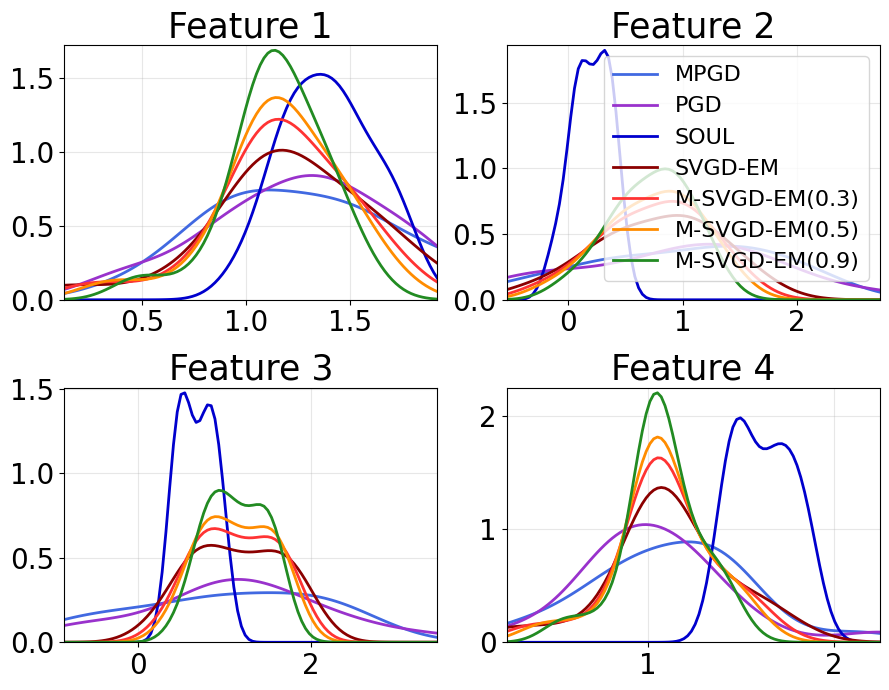

In [8]:
# Extract final particle clouds X^{1:N}_K:
q_pgd = X_pgd[-1]
q_soul = X_soul[-1]
q_svgd = X_svgd[-1]
q_acc03 = X_acc03[-1]
q_acc05 = X_acc05[-1]
q_acc09 = X_acc09[-1]
q_mpgd = x_mpgd[-1]

fig = plt.figure(figsize=(9, 7), constrained_layout=False)
axes = fig.subplots(2, 2)
axes = axes.flatten()

for i in range(4):
    kde_min = np.min([q_pgd[:, i], q_soul[:, i], q_svgd[:, i], q_acc03[:, i], q_acc05[:, i], q_acc09[:, i]])
    kde_max = np.max([q_pgd[:, i], q_soul[:, i], q_svgd[:, i], q_acc03[:, i], q_acc05[:, i], q_acc09[:, i]])
    xaxis = np.linspace(kde_min, kde_max, num=100)

    kde_pgd = stats.gaussian_kde(q_pgd[:, i])(xaxis)
    kde_soul = stats.gaussian_kde(q_soul[:, i])(xaxis)
    kde_svgd = stats.gaussian_kde(q_svgd[:, i])(xaxis)
    kde_acc03 = stats.gaussian_kde(q_acc03[:, i])(xaxis)
    kde_acc05 = stats.gaussian_kde(q_acc05[:, i])(xaxis)
    kde_acc09 = stats.gaussian_kde(q_acc09[:, i])(xaxis)
    kde_mpgd = stats.gaussian_kde(q_mpgd[:, i])(xaxis)

    # KDEs
    axes[i].plot(xaxis, kde_mpgd, label='MPGD', color=colors['mpgd'], linewidth=2)
    axes[i].plot(xaxis, kde_pgd, label='PGD', color=colors['pgd'], linewidth=2)
    axes[i].plot(xaxis, kde_soul, label='SOUL', color=colors['soul'], linewidth=2)
    axes[i].plot(xaxis, kde_svgd, label='SVGD-EM', color=colors['svgd'], linewidth=2)
    axes[i].plot(xaxis, kde_acc03, label='M-SVGD-EM(0.3)', color=colors['acc03'], linewidth=2)
    axes[i].plot(xaxis, kde_acc05, label='M-SVGD-EM(0.5)', color=colors['acc05'], linewidth=2)
    axes[i].plot(xaxis, kde_acc09, label='M-SVGD-EM(0.9)', color=colors['acc09'], linewidth=2)
    axes[i].set_title(f'Feature {i+1}', fontsize=25)
    axes[i].set_ylim([0, 1.02*np.max([kde_pgd, kde_soul, kde_svgd, kde_acc03, kde_acc05, kde_acc09])])
    axes[i].set_xlim([kde_min, kde_max])
    axes[i].grid(alpha=0.3)
    axes[i].tick_params(axis='x', labelsize=20)
    axes[i].tick_params(axis='y', labelsize=20)
axes[1].legend(fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"wisconsin_kde_comparison_marks.pdf"), dpi=300, bbox_inches='tight')
plt.show()

# Experiment 2 (Joint learning rate analysis on predictive performance)

- We run this for 10 different seeds for 100 different learning rates / step sizes
- Each replication has a different train test split.

In [18]:
jnp.logspace(-10, 2, num=100) # Learning rates

Array([1.00000001e-10, 1.32194075e-10, 1.74752740e-10, 2.31012792e-10,
       3.05385217e-10, 4.03702072e-10, 5.33670219e-10, 7.05480452e-10,
       9.32603439e-10, 1.23284649e-09, 1.62975011e-09, 2.15443308e-09,
       2.84803936e-09, 3.76493947e-09, 4.97702679e-09, 6.57933485e-09,
       8.69749162e-09, 1.14975682e-08, 1.51991042e-08, 2.00923385e-08,
       2.65608815e-08, 3.51119134e-08, 4.64158703e-08, 6.13591027e-08,
       8.11131002e-08, 1.07226718e-07, 1.41747520e-07, 1.87381630e-07,
       2.47707419e-07, 3.27454899e-07, 4.32876476e-07, 5.72237070e-07,
       7.56462725e-07, 9.99999997e-07, 1.32194077e-06, 1.74752745e-06,
       2.31013041e-06, 3.05385561e-06, 4.03701642e-06, 5.33669663e-06,
       7.05480488e-06, 9.32603416e-06, 1.23284653e-05, 1.62975193e-05,
       2.15443306e-05, 2.84803609e-05, 3.76493517e-05, 4.97702677e-05,
       6.57933488e-05, 8.69749128e-05, 1.14975686e-04, 1.51991044e-04,
       2.00923270e-04, 2.65608833e-04, 3.51119146e-04, 4.64158977e-04,
      

In [13]:
def predict_prob(f, X):
    """Returns label maximizing the approximate posterior predictive 
    distribution defined by the cloud X, vectorized over feature vectors f.
    """
    s = vmap(lambda x: tfd.Bernoulli(logits=jnp.matmul(f, x)).mean())(X).mean(0)# monte carlo estimation taking eg. x_1 in Real^(9)
    return s

def test_error(f, l, X):
    """Returns fraction of misclassified test points."""
    s = predict_prob(f, X)
    pred = np.zeros((f[:, 0].size, 1))
    pred[s >= 1/2] = 1
    return np.abs(l - pred).mean()

def lppd(f, l, X):
    """Returns log pointwise predictive density."""
    s = vmap(lambda x: tfd.Bernoulli(logits=jnp.matmul(f, x)).log_prob(l.squeeze()))(X).mean()
    return s

In [14]:
seeds = [0, 1, 2, 3, 4]

# Learning rates/Step Size
step_sizes = jnp.logspace(-7, 2, num=100)

K = 500  # Number of steps
N=20 # Number of particles. Running time 5 min 9.0
#N=20 Running time 5 min 50 seconds
#N=100 Running time 22 minutes 14.4 seconds 
pgd_errors = []
soul_errors = []
svgd_errors = []
# acc03_errors = []
# acc05_errors = []
acc09_errors = []

pgd_lppd = []
soul_lppd = []
svgd_lppd = []
# acc03_lppd = []
# acc05_lppd = []
acc09_lppd = []

for seed in seeds:
    
    ftrain, ftest, ltrain, ltest = train_test_split(features, labels, test_size=0.2, random_state=seed)

    model = LogisticRegression()
    data = Dataset(ftrain, ltrain)

    key = jr.PRNGKey(seed)
    key, subkey = jr.split(key)

    th0 = jnp.array([0.0])  # Parameter Initialization at zero.
    X0 = jr.normal(subkey, (N, D))  # Particle Initilization.

    for lr in step_sizes:
        print(f'Learning rate{lr}',f'and seed {seed}')
        key_pgd, key_soul = jr.split(key)
        
        latent_opt = ox.sgd(lr)
        theta_opt = ox.sgd(lr)

        X_pgd, th_pgd = pgd(model, data, X0, th0, K, theta_step_size=lr, latent_step_size=lr, key=key_pgd)
        X_soul, th_soul = soul(model, data, X0, th0, K, theta_step_size=lr, latent_step_size=lr, key=key_soul)
        
        X_svgd, th_svgd = m_svgd_em(model=model, 
            data=data, 
            latent_init=X0, 
            theta_init=th0, 
            latent_optimiser=latent_opt,
            theta_optimiser=theta_opt, 
            num_steps=K,
            e_acceleration=0.0, m_acceleration=0.0)
            
        # X_acc03, th_acc03 = m_svgd_em(model=model, 
        #     data=data, 
        #     latent_init=X0, 
        #     theta_init=th0, 
        #     latent_optimiser=latent_opt,
        #     theta_optimiser=theta_opt, 
        #     num_steps=K,
        #     e_acceleration=0.3, m_acceleration=0.3)
            
        # X_acc05, th_acc05 = m_svgd_em(model=model, 
        #     data=data, 
        #     latent_init=X0, 
        #     theta_init=th0, 
        #     latent_optimiser=latent_opt,
        #     theta_optimiser=theta_opt, 
        #     num_steps=K,
        #     e_acceleration=0.5, m_acceleration=0.5)
            
        X_acc09, th_acc09 = m_svgd_em(model=model, 
            data=data, 
            latent_init=X0, 
            theta_init=th0, 
            latent_optimiser=latent_opt,
            theta_optimiser=theta_opt, 
            num_steps=K,
            e_acceleration=0.9, m_acceleration=0.9)

        pgd_errors.append(test_error(ftest, ltest, X_pgd[-1]))
        soul_errors.append(test_error(ftest, ltest, X_soul[-1]))
        svgd_errors.append(test_error(ftest, ltest, X_svgd[-1]))
        pgd_lppd.append(lppd(ftest, ltest, X_pgd[-1]))
        soul_lppd.append(lppd(ftest, ltest, X_soul[-1]))
        svgd_lppd.append(lppd(ftest, ltest, X_svgd[-1]))
        acc09_lppd.append(lppd(ftest, ltest, X_acc09[-1]))



soul_errors = jnp.array(soul_errors).reshape(-1, step_sizes.shape[0])
svgd_errors = jnp.array(svgd_errors).reshape(-1, step_sizes.shape[0])
#acc03_errors = jnp.array(acc03_errors).reshape(-1, step_sizes.shape[0])
#acc05_errors = jnp.array(acc05_errors).reshape(-1, step_sizes.shape[0])
        #acc05_lppd.append(lppd(ftest, ltest, X_acc05[-1]))
        #acc09_lppd.append(lppd(ftest, ltest, X_acc09[-1]))


pgd_errors = jnp.array(pgd_errors).reshape(-1, step_sizes.shape[0])
soul_errors = jnp.array(soul_errors).reshape(-1, step_sizes.shape[0])
svgd_errors = jnp.array(svgd_errors).reshape(-1, step_sizes.shape[0])
#acc03_errors = jnp.array(acc03_errors).reshape(-1, step_sizes.shape[0])
#acc05_errors = jnp.array(acc05_errors).reshape(-1, step_sizes.shape[0])
#acc09_errors = jnp.array(acc09_errors).reshape(-1, step_sizes.shape[0])

pgd_lppd = jnp.array(pgd_lppd).reshape(-1, step_sizes.shape[0])
soul_lppd = jnp.array(soul_lppd).reshape(-1, step_sizes.shape[0])
svgd_lppd = jnp.array(svgd_lppd).reshape(-1, step_sizes.shape[0])
#acc03_lppd = jnp.array(acc03_lppd).reshape(-1, step_sizes.shape[0])
#acc05_lppd = jnp.array(acc05_lppd).reshape(-1, step_sizes.shape[0])
#acc09_lppd = jnp.array(acc09_lppd).reshape(-1, step_sizes.shape[0])

# Median RBF Total execution time 287.85 seconds

Learning rate1.0000000116860974e-07 and seed 0
Learning rate1.2328465004429745e-07 and seed 0
Learning rate1.5199121605746768e-07 and seed 0
Learning rate1.8738163021225773e-07 and seed 0
Learning rate2.31012791118701e-07 and seed 0
Learning rate2.848036046998459e-07 and seed 0
Learning rate3.5111912666252465e-07 and seed 0
Learning rate4.328759928284853e-07 and seed 0
Learning rate5.336702315617003e-07 and seed 0
Learning rate6.579327873623697e-07 and seed 0
Learning rate8.111309739433636e-07 and seed 0
Learning rate9.999999974752427e-07 and seed 0
Learning rate1.2328464435995556e-06 and seed 0
Learning rate1.5199121889963862e-06 and seed 0
Learning rate1.8738184053290752e-06 and seed 0
Learning rate2.31012791118701e-06 and seed 0
Learning rate2.848036046998459e-06 and seed 0
Learning rate3.5111913803120842e-06 and seed 0
Learning rate4.328760041971691e-06 and seed 0
Learning rate5.336702542990679e-06 and seed 0
Learning rate6.57933469483396e-06 and seed 0
Learning rate8.1113103078678

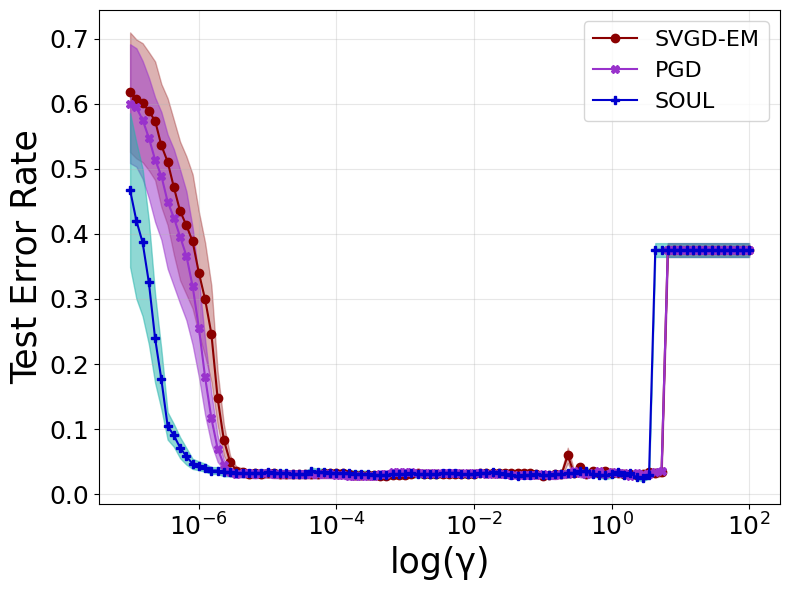

In [16]:
plt.figure(figsize=(8, 6))
#plt.plot(theta_step_sizes, pa_errors.mean(0), label='PA-SVGD', color='r')
#plt.fill_between(theta_step_sizes, pa_errors.mean(0) - pa_errors.std(0)/jnp.sqrt(10), pa_errors.mean(0) + pa_errors.std(0)/jnp.sqrt(10), alpha=0.5, color='r')

plt.plot(step_sizes, svgd_errors.mean(0), label='SVGD-EM', color='#8B0000', marker='o', markersize=6)
plt.fill_between(step_sizes, svgd_errors.mean(0) - svgd_errors.std(0)/jnp.sqrt(10), svgd_errors.mean(0) + svgd_errors.std(0)/jnp.sqrt(10), alpha=0.3, color='#8B0000')

plt.plot(step_sizes, pgd_errors.mean(0), label='PGD', color='#9932CC',marker='X',markersize=6)
plt.fill_between(step_sizes, pgd_errors.mean(0) - pgd_errors.std(0)/jnp.sqrt(10), pgd_errors.mean(0) + pgd_errors.std(0)/jnp.sqrt(10), alpha=0.5, color='#9932CC')

plt.plot(step_sizes, soul_errors.mean(0), label='SOUL', color='#0000CD',marker='P',markersize=6)
plt.fill_between(step_sizes, soul_errors.mean(0) - soul_errors.std(0)/jnp.sqrt(10), soul_errors.mean(0) + soul_errors.std(0)/jnp.sqrt(10), alpha=0.5, color='#20B2AA')

#plt.plot(step_sizes, ta_errors.mean(0), label='TA-SVGD', color='purple')
#plt.fill_between(step_sizes, ta_errors.mean(0) - ta_errors.std(0)/jnp.sqrt(10), ta_errors.mean(0) + ta_errors.std(0)/jnp.sqrt(10), alpha=0.5, color='purple')

# plt.plot(theta_step_sizes, acc03_errors.mean(0), label='M-SVGD-EM(0.3)', color='#FF3333', marker='s', markersize=4)
# plt.fill_between(theta_step_sizes, acc03_errors.mean(0) - acc03_errors.std(0)/jnp.sqrt(10), acc03_errors.mean(0) + acc03_errors.std(0)/jnp.sqrt(10), alpha=0.3, color='#FF3333')

# plt.plot(theta_step_sizes, acc05_errors.mean(0), label='M-SVGD-EM(0.5)', color='#FF8C00', marker='^', markersize=4)
# plt.fill_between(theta_step_sizes, acc05_errors.mean(0) - acc05_errors.std(0)/jnp.sqrt(10), acc05_errors.mean(0) + acc05_errors.std(0)/jnp.sqrt(10), alpha=0.3, color='#FF8C00')

#plt.plot(step_sizes, acc09_errors.mean(0), label='M-SVGD-EM(0.9)', color='#228B22', marker='d', markersize=4)
#plt.fill_between(step_sizes, acc09_errors.mean(0) - acc09_errors.std(0)/jnp.sqrt(10), acc09_errors.mean(0) + acc09_errors.std(0)/jnp.sqrt(10), alpha=0.3, color='#228B22')

plt.xscale('log')
plt.xlabel('log(γ)',fontsize=25)
plt.ylabel('Test Error Rate',fontsize=25)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, f'logistic_regression_Test_error_N{N}_M.pdf'), 
            dpi=300, bbox_inches='tight')

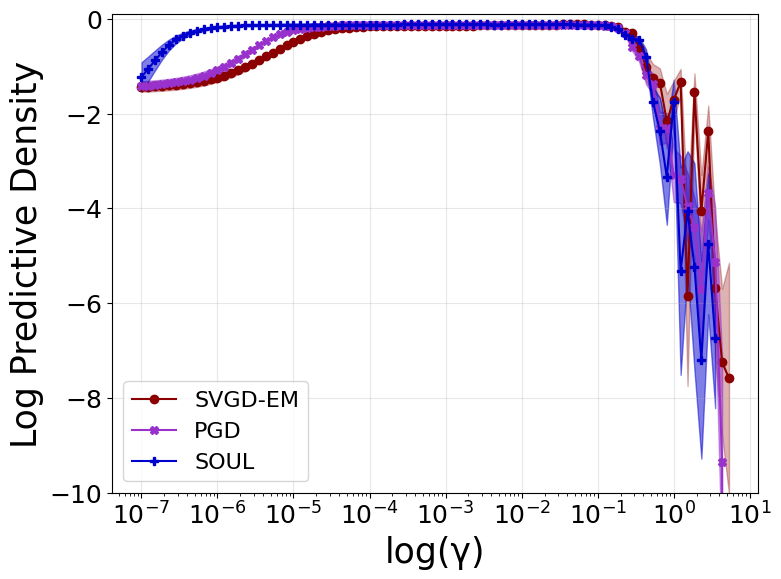

In [18]:
plt.figure(figsize=(8, 6))
#plt.plot(theta_step_sizes, pa_errors.mean(0), label='PA-SVGD', color='r')
#plt.fill_between(theta_step_sizes, pa_errors.mean(0) - pa_errors.std(0)/jnp.sqrt(10), pa_errors.mean(0) + pa_errors.std(0)/jnp.sqrt(10), alpha=0.5, color='r')

plt.plot(step_sizes, svgd_lppd.mean(0), label='SVGD-EM', color='#8B0000', marker='o', markersize=6)
plt.fill_between(step_sizes, svgd_lppd.mean(0) - svgd_lppd.std(0)/jnp.sqrt(10), svgd_lppd.mean(0) + svgd_lppd.std(0)/jnp.sqrt(10), alpha=0.3, color='#8B0000')

plt.plot(step_sizes, pgd_lppd.mean(0), label='PGD', color='#9932CC', marker='X', markersize=6)
plt.fill_between(step_sizes, pgd_lppd.mean(0) - pgd_lppd.std(0)/jnp.sqrt(10), pgd_lppd.mean(0) + pgd_lppd.std(0)/jnp.sqrt(10), alpha=0.5, color='#9932CC')

plt.plot(step_sizes, soul_lppd.mean(0), label='SOUL', color='#0000CD', marker='P', markersize=6)
plt.fill_between(step_sizes, soul_lppd.mean(0) - soul_lppd.std(0)/jnp.sqrt(10), soul_lppd.mean(0) + soul_lppd.std(0)/jnp.sqrt(10), alpha=0.5, color='#0000CD')

#plt.plot(theta_step_sizes, ta_errors.mean(0), label='TA-SVGD', color='purple')
#plt.fill_between(theta_step_sizes, ta_errors.mean(0) - ta_errors.std(0)/jnp.sqrt(10), ta_errors.mean(0) + ta_errors.std(0)/jnp.sqrt(10), alpha=0.5, color='purple')

# plt.plot(theta_step_sizes, acc03_lppd.mean(0), label='M-SVGD-EM(0.3)', color='#FF3333', marker='s', markersize=4)
# plt.fill_between(theta_step_sizes, acc03_lppd.mean(0) - acc03_lppd.std(0)/jnp.sqrt(10), acc03_lppd.mean(0) + acc03_lppd.std(0)/jnp.sqrt(10), alpha=0.3, color='#FF3333')

# plt.plot(theta_step_sizes, acc05_lppd.mean(0), label='M-SVGD-EM(0.5)', color='#FF8C00', marker='^', markersize=4)
# plt.fill_between(theta_step_sizes, acc05_lppd.mean(0) - acc05_lppd.std(0)/jnp.sqrt(10), acc05_lppd.mean(0) + acc05_lppd.std(0)/jnp.sqrt(10), alpha=0.3, color='#FF8C00')

#plt.plot(step_sizes, acc09_lppd.mean(0), label='M-SVGD-EM(0.9)', color='#228B22', marker='d', markersize=4)
#plt.fill_between(step_sizes, acc09_lppd.mean(0) - acc09_lppd.std(0)/jnp.sqrt(10), acc09_lppd.mean(0) + acc09_lppd.std(0)/jnp.sqrt(10), alpha=0.3, color='#228B22')

plt.xscale('log')
plt.xlabel('log(γ)',fontsize=25)
plt.ylabel('Log Predictive Density',fontsize=25)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(-10, 0.1)
plt.savefig(os.path.join(save_dir, f'logistic_regression_Lppd_N{N}_M.pdf'), 
            dpi=300, bbox_inches='tight')

In [ ]:
alpha = np.array([0.0,0.3,0.5,0.7, 0.9])  # Different acceleration values
N_grid = 20   # Number of particles
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
seeds_grid = seeds[:9] # change in case you want to use more or less seeds
K = [50,100,150,200,250] 
lr = 1e-5
error_grid = np.zeros((len(alpha), len(K)))
error_grid_std = np.zeros((len(alpha), len(K)))

# Run for multiple seeds and average
for seed_idx, seed in enumerate(seeds_grid):
    print(f"Processing seed {seed_idx+1}/{len(seeds_grid)}")
    ftrain, ftest, ltrain, ltest = train_test_split(features, labels, test_size=0.2, random_state=seed)
    model = LogisticRegression()
    data = Dataset(ftrain, ltrain)
    
    # Initialize particles
    key = jr.PRNGKey(seed)
    key, subkey = jr.split(key)
    th0 = jnp.array([0.0])
    X0 = jr.normal(subkey, (N_grid, D))
    for i, acc in enumerate(alpha):
        # Run M-SVGD-EM with the current acceleration value
        X_result, th_result = m_svgd_em(
            model=model, 
            data=data, 
            latent_init=X0, 
            theta_init=th0, 
            latent_optimiser=ox.sgd(lr),
            theta_optimiser=ox.sgd(lr), 
            num_steps=max(K),
            e_acceleration=acc,
            m_acceleration=acc
        )
        for j, k in enumerate(K):
            error = test_error(ftest, ltest, X_result[k-1])
            error_grid[i, j] += error / len(seeds_grid)  # Average across seeds
            error_grid_std[i,j] += (error - error_grid[i, j])**2 / len(seeds_grid)  # Calculate variance across seeds
            

Processing seed 1/9
Processing seed 2/9
Processing seed 3/9
Processing seed 4/9
Processing seed 5/9
Processing seed 6/9
Processing seed 7/9
Processing seed 8/9
Processing seed 9/9


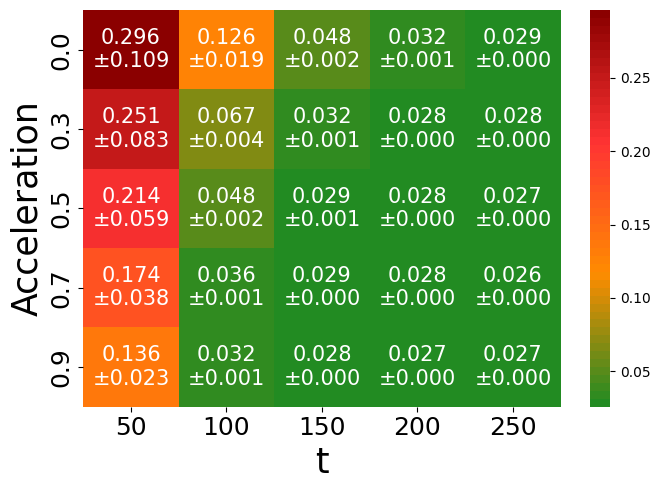

In [ ]:
plt.figure(figsize=(7, 5))
color_list = [colors['acc09'], colors['acc05'], colors['acc03'], colors['svgd']]
custom_cmap = LinearSegmentedColormap.from_list("custom_colormap", color_list, N=50)

annotations = []
for i in range(len(alpha)):
    row = []
    for j in range(len(K)):
        mean_value = error_grid[i, j]
        std_value = error_grid_std[i,j]
        row.append(f"{mean_value:.3f}\n±{std_value:.3f}")
    annotations.append(row)

ax = sns.heatmap(error_grid, cmap=custom_cmap, 
                 xticklabels=[f'{x}' for x in K],
                 yticklabels=[f'{y:.1f}' for y in alpha],
                 annot=annotations, fmt="", annot_kws={"size": 15})

plt.xlabel('t', fontsize=25)
plt.ylabel('Acceleration', fontsize=25)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, f'wisconsin_error_heatmap_lr{lr}.pdf'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
end = time.time()
print(f"Total execution time: {end - start:.2f} seconds")
#439.12 seconds
#388.81 seconds 
#403.62 seconds 
#429.31 seconds 
#455.89 seconds 
#Average = 423.35 seconds 